# SAM2 Image Segmentation: Official Repo vs Hugging Face Transformers

This notebook compares **SAM2.1 Hiera Large** using two implementations:
1. **Official Meta Repository** (`sam2` package + local checkpoint).
2. **Hugging Face `transformers`** (`Sam2Model` + `Sam2Processor`).

**Goal:**
Compare the two implementations on the same images, with the same SAM2.1 Hiera Large checkpoint, the same prompts, and the same ground-truth masks.

The quantitative comparison uses point and box prompts. The automatic-mask mode is useful for checking the official pipeline, but it is not used as the main comparison because the two interfaces would otherwise use different prompt protocols.

This is a controlled multi-image evaluation, not a full benchmark.

## Experimental setup

We use the Oxford-IIIT Pet segmentation dataset because it provides pixel-level foreground annotations for multiple images. For each selected image, the prompt is derived from the ground-truth mask so that both implementations receive exactly the same point or box.

This creates an oracle-prompt evaluation: the prompt itself is not being evaluated. The experiment measures how consistently the two implementations turn the same prompt and image into a segmentation mask.

Metrics reported at the end are IoU, Dice/F1, precision, recall, and inference time.

In [ ]:
!git clone https://github.com/facebookresearch/sam2.git
%cd sam2
!pip install -e .

# Download SAM2.1 checkpoints (~1GB total)
%cd checkpoints
!bash download_ckpts.sh
%cd ..

In [ ]:
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [ ]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision.datasets import OxfordIIITPet
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

from transformers import Sam2Processor, Sam2Model

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

## Checkpoint

Both implementations use **SAM2.1 Hiera Large**. The official repository loads `sam2.1_hiera_large.pt`, while Hugging Face loads the corresponding `facebook/sam2.1-hiera-large` model.

The serialized files are different formats, but they represent the same SAM2.1 Hiera Large checkpoint family. The model identity is therefore controlled while the software interface changes.

In [ ]:
checkpoint = "checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
if not os.path.exists(checkpoint):
    !cd sam2/checkpoints && bash download_ckpts.sh

sam_model = build_sam2(model_cfg, checkpoint, device=device)
predictor = SAM2ImagePredictor(sam_model)

hf_model_name = "facebook/sam2.1-hiera-large"
model = Sam2Model.from_pretrained(hf_model_name).to(device)
processor = Sam2Processor.from_pretrained(hf_model_name)

print("Official checkpoint:", checkpoint)
print("Hugging Face checkpoint:", hf_model_name)

## Multi-Image Evaluation Set

A single image is useful for checking whether the pipeline works, but it is not sufficient for a meaningful comparison. We therefore use the same fixed set of images for both implementations.

The dataset is downloaded through `torchvision`. The first five images are used to keep the notebook practical in a normal Colab runtime.

In [ ]:
root = "data"
dataset = OxfordIIITPet(root=root, split="test", target_types="segmentation", download=True)

eval_indices = [0, 1, 2, 3, 4]
eval_data = []

for idx in eval_indices:
    image, mask = dataset[idx]
    image = image.convert("RGB")
    mask = np.array(mask)

    gt_mask = (mask == 1)
    ignore_mask = (mask == 3)
    ys, xs = np.where(gt_mask)

    box = [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]
    y_mid = int((ys.min() + ys.max()) / 2)
    x_mid = int((xs.min() + xs.max()) / 2)

    inside = np.argwhere(gt_mask)
    point_y, point_x = inside[len(inside) // 2]

    eval_data.append({
        "index": idx,
        "image": image,
        "gt_mask": gt_mask,
        "ignore_mask": ignore_mask,
        "box": box,
        "point": [int(point_x), int(point_y)]
    })

print(f"Evaluation images: {len(eval_data)}")

In [ ]:
fig, axes = plt.subplots(1, len(eval_data), figsize=(18, 4))

for ax, item in zip(axes, eval_data):
    ax.imshow(item["image"])
    x1, y1, x2, y2 = item["box"]
    ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2))
    ax.scatter(item["point"][0], item["point"][1], s=35)
    ax.axis("off")
    ax.set_title(f"Image {item['index']}")

plt.show()

## Evaluation metrics

For each image, the predicted mask is compared with the ground-truth foreground mask.

- **IoU** = intersection over union.
- **Dice/F1** = overlap-based F1 score.
- **Precision** = fraction of predicted foreground pixels that are correct.
- **Recall** = fraction of ground-truth foreground pixels that are recovered.

The main comparison uses the same selected mask candidate for both implementations: the candidate with the highest model-reported IoU score.

Inference time is measured separately for each implementation. The first inference is excluded from timing because model warm-up and CUDA initialization can otherwise dominate the result.

In [ ]:
def mask_metrics(pred, gt, ignore=None):
    pred = np.asarray(pred).astype(bool)
    gt = np.asarray(gt).astype(bool)

    if ignore is not None:
        valid = ~np.asarray(ignore).astype(bool)
        pred = pred & valid
        gt = gt & valid
    else:
        valid = np.ones_like(gt, dtype=bool)

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred & valid, ~gt).sum()
    fn = np.logical_and(~pred & valid, gt).sum()

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    dice = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0
    iou = tp / (tp + fp + fn) if tp + fp + fn else 0.0

    return {
        "IoU": iou,
        "Dice": dice,
        "Precision": precision,
        "Recall": recall
    }

def sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

## Part 1: Official Meta Repository

We first run the official SAM2 predictor using the same point and box prompts that will later be passed to the Hugging Face implementation.

In [ ]:
official_results = []

# Warm-up (both prompt types, so neither timed run absorbs first-call init cost)
predictor.set_image(np.array(eval_data[0]["image"]))
predictor.predict(point_coords=np.array([eval_data[0]["point"]]), point_labels=np.array([1]), multimask_output=True)
predictor.predict(box=np.array(eval_data[0]["box"], dtype=np.float32), multimask_output=True)

for item in eval_data:
    image_array = np.array(item["image"])
    predictor.set_image(image_array)

    row = {"index": item["index"]}

    for prompt_type in ["point", "box"]:
        if prompt_type == "point":
            point_coords = np.array([item["point"]])
            point_labels = np.array([1])
            box = None
        else:
            point_coords = None
            point_labels = None
            box = np.array(item["box"], dtype=np.float32)

        sync()
        start = time.perf_counter()

        masks, scores, logits = predictor.predict(
            point_coords=point_coords,
            point_labels=point_labels,
            box=box,
            multimask_output=True,
        )

        sync()
        elapsed = time.perf_counter() - start

        best_idx = int(np.argmax(scores))
        best_mask = masks[best_idx].astype(bool)

        metrics = mask_metrics(best_mask, item["gt_mask"], item["ignore_mask"])
        row[f"{prompt_type}_time"] = elapsed
        row[f"{prompt_type}_score"] = float(scores[best_idx])
        row[f"{prompt_type}_mask"] = best_mask
        row[f"{prompt_type}_iou"] = metrics["IoU"]
        row[f"{prompt_type}_dice"] = metrics["Dice"]
        row[f"{prompt_type}_precision"] = metrics["Precision"]
        row[f"{prompt_type}_recall"] = metrics["Recall"]

    official_results.append(row)

print("Official evaluation complete.")

## Part 2: Hugging Face Transformers

The Hugging Face model receives the same image and the same point or box coordinates. Post-processing converts the predicted masks back to the original image size before metric calculation.

In [ ]:
shf_results = []

# Warm-up
warm_image = eval_data[0]["image"]
warm_point = [[[[eval_data[0]["point"][0], eval_data[0]["point"][1]]]]]
warm_label = [[[1]]]

warm_inputs = processor(
    images=warm_image,
    input_points=warm_point,
    input_labels=warm_label,
    return_tensors="pt",
).to(device)

with torch.inference_mode():
    _ = model(**warm_inputs)

warm_box_inputs = processor(
    images=warm_image,
    input_boxes=[[[eval_data[0]["box"][0], eval_data[0]["box"][1], eval_data[0]["box"][2], eval_data[0]["box"][3]]]],
    return_tensors="pt",
).to(device)

with torch.inference_mode():
    _ = model(**warm_box_inputs)

for item in eval_data:
    image = item["image"]
    row = {"index": item["index"]}

    for prompt_type in ["point", "box"]:
        if prompt_type == "point":
            input_points = [[[[item["point"][0], item["point"][1]]]]]
            input_labels = [[[1]]]

            inputs = processor(
                images=image,
                input_points=input_points,
                input_labels=input_labels,
                return_tensors="pt",
            ).to(device)
        else:
            input_boxes = [[[item["box"][0], item["box"][1], item["box"][2], item["box"][3]]]]

            inputs = processor(
                images=image,
                input_boxes=input_boxes,
                return_tensors="pt",
            ).to(device)

        sync()
        start = time.perf_counter()

        with torch.inference_mode():
            outputs = model(**inputs)

        sync()
        elapsed = time.perf_counter() - start

        post_process_kwargs = {"original_sizes": inputs["original_sizes"].cpu()}
        if "reshaped_input_sizes" in inputs:
            post_process_kwargs["reshaped_input_sizes"] = inputs["reshaped_input_sizes"].cpu()

        masks = processor.post_process_masks(
            outputs.pred_masks.cpu(),
            **post_process_kwargs,
        )[0]

        iou_scores = outputs.iou_scores[0, 0]
        best_idx = int(torch.argmax(iou_scores))
        best_mask = masks[0, best_idx].numpy().astype(bool)

        metrics = mask_metrics(best_mask, item["gt_mask"], item["ignore_mask"])
        row[f"{prompt_type}_time"] = elapsed
        row[f"{prompt_type}_score"] = float(iou_scores[best_idx].cpu())
        row[f"{prompt_type}_mask"] = best_mask
        row[f"{prompt_type}_iou"] = metrics["IoU"]
        row[f"{prompt_type}_dice"] = metrics["Dice"]
        row[f"{prompt_type}_precision"] = metrics["Precision"]
        row[f"{prompt_type}_recall"] = metrics["Recall"]

    hf_results.append(row)

print("Hugging Face evaluation complete.")

## Visual comparison

The visual examples are not used as the primary evidence. They are included to inspect whether the quantitative results correspond to the actual masks.

In [ ]:
for item, official, hf in zip(eval_data, official_results, hf_results):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(item["image"])
    axes[0].imshow(np.ma.masked_where(~item["gt_mask"], item["gt_mask"]), cmap="spring", alpha=0.6)
    axes[0].set_title(f"Ground Truth — Image {item['index']}")
    axes[0].axis("off")

    axes[1].imshow(item["image"])
    axes[1].imshow(np.ma.masked_where(~official["point_mask"], official["point_mask"]), cmap="spring", alpha=0.6)
    axes[1].set_title(f"Official — Point IoU {official['point_iou']:.3f}")
    axes[1].axis("off")

    axes[2].imshow(item["image"])
    axes[2].imshow(np.ma.masked_where(~hf["point_mask"], hf["point_mask"]), cmap="spring", alpha=0.6)
    axes[2].set_title(f"HF — Point IoU {hf['point_iou']:.3f}")
    axes[2].axis("off")

    plt.show()

## Quantitative comparison

The results are aggregated over the same five images. The metrics are calculated from the ground-truth masks rather than from the model's internal confidence scores.

In [ ]:
rows = []

for prompt_type in ["point", "box"]:
    for name, results in [("Official", official_results), ("Hugging Face", hf_results)]:
        for metric in ["IoU", "Dice", "Precision", "Recall"]:
            values = [r[f"{prompt_type}_{metric.lower()}"] for r in results]
            rows.append({
                "Implementation": name,
                "Prompt": prompt_type,
                "Metric": metric,
                "Mean": np.mean(values),
                "Median": np.median(values)
            })

metrics_df = pd.DataFrame(rows)
print("Note: n = 5 images; means/medians are indicative, not statistically robust.")
display(metrics_df.round(4))

In [ ]:
time_rows = []

for prompt_type in ["point", "box"]:
    for name, results in [("Official", official_results), ("Hugging Face", hf_results)]:
        values = [r[f"{prompt_type}_time"] for r in results]
        time_rows.append({
            "Implementation": name,
            "Prompt": prompt_type,
            "Mean time (s)": np.mean(values),
            "Median time (s)": np.median(values),
            "Images/sec": 1 / np.mean(values)
        })

time_df = pd.DataFrame(time_rows)
display(time_df.round(4))

In [ ]:
comparison_rows = []

for prompt_type in ["point", "box"]:
    for metric in ["IoU", "Dice", "Precision", "Recall"]:
        official_mean = np.mean([r[f"{prompt_type}_{metric.lower()}"] for r in official_results])
        hf_mean = np.mean([r[f"{prompt_type}_{metric.lower()}"] for r in hf_results])

        comparison_rows.append({
            "Prompt": prompt_type,
            "Metric": metric,
            "Official": official_mean,
            "Hugging Face": hf_mean,
            "HF - Official": hf_mean - official_mean
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.round(4))

In [ ]:
plot_df = comparison_df[comparison_df["Metric"].isin(["IoU", "Dice"])].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
width = 0.35

ax.bar(x - width/2, plot_df["Official"], width, label="Official")
ax.bar(x + width/2, plot_df["Hugging Face"], width, label="Hugging Face")

ax.set_xticks(x)
ax.set_xticklabels([f"{p} — {m}" for p, m in zip(plot_df["Prompt"], plot_df["Metric"])])
ax.set_ylabel("Score")
ax.set_title("SAM2.1 Hiera Large — Segmentation Comparison")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

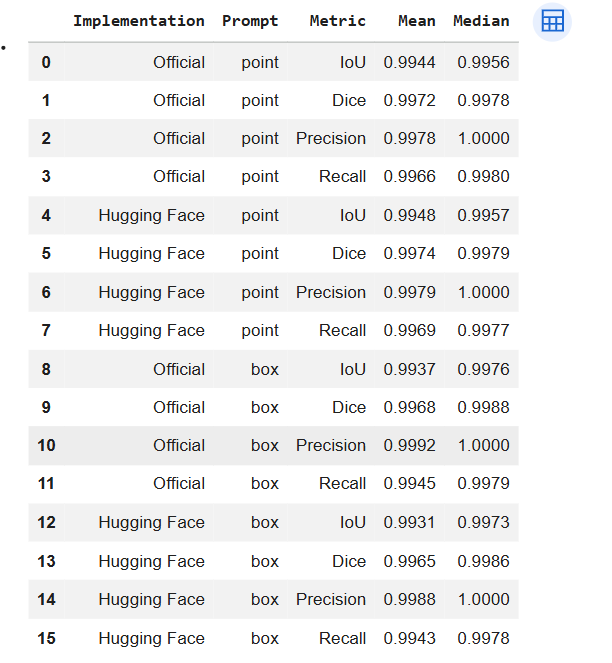

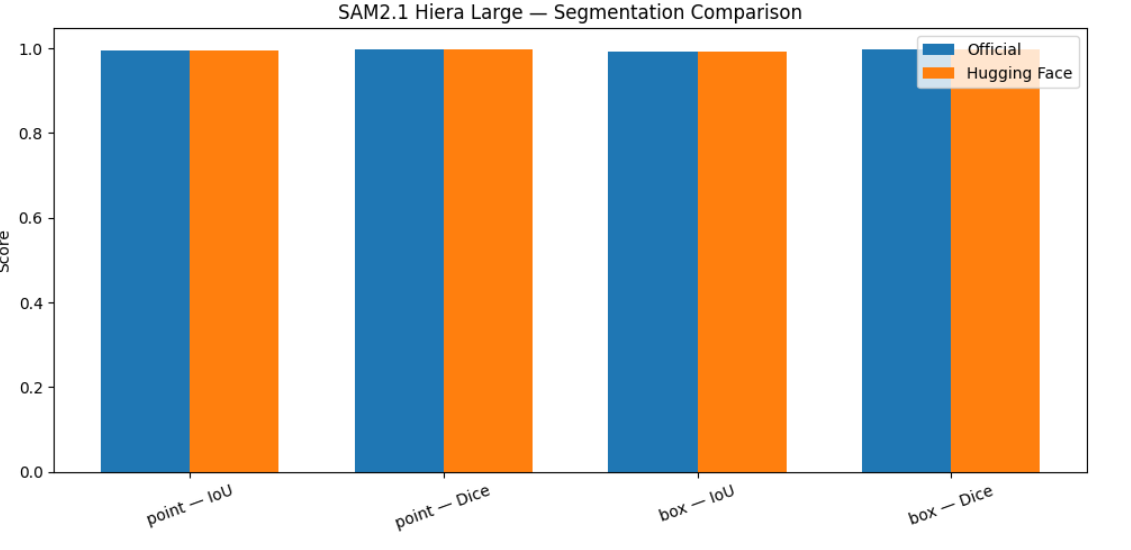

# Interpretation and Limitations

The SAM2.1 Hiera Large results show very high segmentation performance for both the Official and Hugging Face implementations. IoU and Dice scores are around 0.99, with precision and recall also close to 1.00, indicating that both implementations produced masks highly similar to the ground-truth masks.

The results suggest that the Official and Hugging Face implementations produce highly comparable segmentation outputs when using the same model, images, prompts, and evaluation masks. Small differences between the implementations should not automatically be interpreted as one being better.

**Limitations:** The evaluation uses only five images, so the results are not statistically robust or representative of general SAM2 performance. The point and box prompts are also derived from the ground-truth masks, which makes the experiment controlled but less representative of real user interaction. In addition, inference time can vary depending on hardware, CUDA, and software versions.

Overall, both implementations demonstrate excellent segmentation quality and strong agreement, but a larger dataset and more realistic user-generated prompts would be needed for a stronger benchmark.